# Brenstein Vazirani

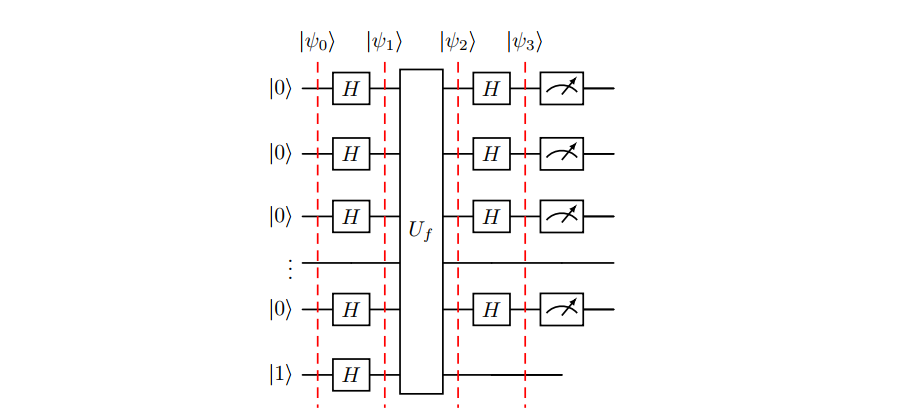

In [1]:
from qiskit import *
from qiskit_aer import *
from qiskit.visualization import *
from qiskit.quantum_info import *

import numpy as np

## Visualization Function

In [2]:
def qplot(x):
    return x.draw(scale=0.8, fold=-1, cregbundle=False, initial_state=True)

## Oracle
### $$  c = c_2c_1c_0 = 110 $$

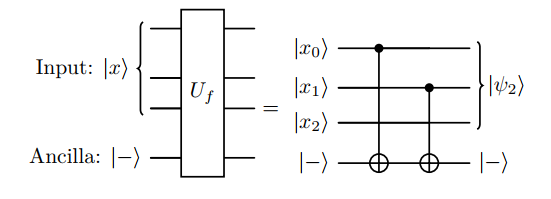

In [18]:
secret_key = '110101010011101010'

In [19]:
# create quantum Register for main system
n = len(secret_key)

qm = QuantumRegister(n, name = 'qubit')
qa = QuantumRegister(1, name = 'ancilla')
cbits = ClassicalRegister(n, name = 'cbits')

In [20]:
# create the Quantum Circuit for BV algorithm
qc = QuantumCircuit(qm, qa, cbits)

# initialization
qc.x(qa)
qc.barrier(label = '|->')

# Apply Hadamard to all qubits
qc.h(range(n+1))
qc.barrier(label = 'H^n+1')

# Oracle
for i in range(n):
    if secret_key[i] == '1':
        qc.cx(qm[i], qa)
qc.barrier(label = 'Oracle')

# Apply Hadamard to main register
qc.h(qm)
qc.barrier()

# Measurement
qc.measure(qm, cbits)


qplot(qc)

|-> ┌───┐ H^n+1                                                    Oracle ┌───┐ ░ ┌─┐                                                   
 qubit_0: |0>───────░──┤ H ├───░─────■──────────────────────────────────────────────────░────┤ H ├─░─┤M├───────────────────────────────────────────────────
                    ░  ├───┤   ░     │                                                  ░    ├───┤ ░ └╥┘┌─┐                                                
 qubit_1: |0>───────░──┤ H ├───░─────┼────■─────────────────────────────────────────────░────┤ H ├─░──╫─┤M├────────────────────────────────────────────────
                    ░  ├───┤   ░     │    │                                             ░    ├───┤ ░  ║ └╥┘┌─┐                                             
 qubit_2: |0>───────░──┤ H ├───░─────┼────┼─────────────────────────────────────────────░────┤ H ├─░──╫──╫─┤M├─────────────────────────────────────────────
                    ░  ├───┤   ░     │    │                                             ░    ├───┤ ░  ║  ║ └╥┘┌─┐                                          
 qubit_3: |0>───────░──┤ H ├───░─────┼────┼────■────────────────────────────────────────░────┤ H ├─░──╫──╫──╫─┤M├──────────────────────────────────────────
                    ░  ├───┤   ░     │    │    │                                        ░    ├───┤ ░  ║  ║  ║ └╥┘┌─┐                                       
 qubit_4: |0>───────░──┤ H ├───░─────┼────┼────┼────────────────────────────────────────░────┤ H ├─░──╫──╫──╫──╫─┤M├───────────────────────────────────────
                    ░  ├───┤   ░     │    │    │                                        ░    ├───┤ ░  ║  ║  ║  ║ └╥┘┌─┐                                    
 qubit_5: |0>───────░──┤ H ├───░─────┼────┼────┼────■───────────────────────────────────░────┤ H ├─░──╫──╫──╫──╫──╫─┤M├────────────────────────────────────
                    ░  ├───┤   ░     │    │    │    │                                   ░    ├───┤ ░  ║  ║  ║  ║  ║ └╥┘┌─┐                                 
 qubit_6: |0>───────░──┤ H ├───░─────┼────┼────┼────┼───────────────────────────────────░────┤ H ├─░──╫──╫──╫──╫──╫──╫─┤M├─────────────────────────────────
                    ░  ├───┤   ░     │    │    │    │                                   ░    ├───┤ ░  ║  ║  ║  ║  ║  ║ └╥┘┌─┐                              
 qubit_7: |0>───────░──┤ H ├───░─────┼────┼────┼────┼────■──────────────────────────────░────┤ H ├─░──╫──╫──╫──╫──╫──╫──╫─┤M├──────────────────────────────
                    ░  ├───┤   ░     │    │    │    │    │                              ░    ├───┤ ░  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐                           
 qubit_8: |0>───────░──┤ H ├───░─────┼────┼────┼────┼────┼──────────────────────────────░────┤ H ├─░──╫──╫──╫──╫──╫──╫──╫──╫─┤M├───────────────────────────
                    ░  ├───┤   ░     │    │    │    │    │                              ░    ├───┤ ░  ║  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐                        
 qubit_9: |0>───────░──┤ H ├───░─────┼────┼────┼────┼────┼──────────────────────────────░────┤ H ├─░──╫──╫──╫──╫──╫──╫──╫──╫──╫─┤M├────────────────────────
                    ░  ├───┤   ░     │    │    │    │    │                              ░    ├───┤ ░  ║  ║  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐                     
qubit_10: |0>───────░──┤ H ├───░─────┼────┼────┼────┼────┼────■─────────────────────────░────┤ H ├─░──╫──╫──╫──╫──╫──╫──╫──╫──╫──╫─┤M├─────────────────────
                    ░  ├───┤   ░     │    │    │    │    │    │                         ░    ├───┤ ░  ║  ║  ║  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐                  
qubit_11: |0>───────░──┤ H ├───░─────┼────┼────┼────┼────┼────┼────■────────────────────░────┤ H ├─░──╫──╫──╫──╫──╫──╫──╫──╫──╫──╫──╫─┤M├──────────────────
                    ░  ├───┤   ░     │    │    │    │    │    │    │                    ░    ├───┤ ░  ║  ║  ║  ║  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐               
qubit_12: |0>───────░──┤ H ├───░─────┼────┼────┼────┼────┼────┼────┼────■───────────────░────┤ H ├─░──╫──╫──╫──╫──╫──╫─

In [21]:
backend = QasmSimulator()
transpiled_qc = transpile(qc.reverse_bits(), backend)
job = backend.run(transpiled_qc, shots = 1)
result = job.result()
counts = result.get_counts()
counts


{'110101010011101010': 1}

In [22]:
secret_key

'110101010011101010'